In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
import seaborn as sns
from itertools import cycle

In [18]:
# Load dataset
df = pd.read_csv(r'reviews_20k.csv')
df = df.iloc[:11000]  # Take only the first 20,000 rows

In [19]:
# Label Encoding: Categorize star ratings into Positive, Neutral, and Negative
def categorize_stars(stars):
    if stars >= 4:
        return "Positive"
    elif stars == 3:
        return "Neutral"
    else:
        return "Negative"
    
df["label"] = df["stars"].apply(categorize_stars)
df.dropna(subset=["stars", "text"], inplace=True)


In [20]:
df

,review_id,user_id,business_id,stars,useful,funny,cool,text,date,label
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11,Neutral
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18,Positive
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30,Neutral
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03,Positive
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15,Positive
...,...,...,...,...,...,...,...,...,...,...
10995,r5kADStFhG0b-Yc-Ln_vxQ,5SY4Ieay446OQbB2wNBBZw,R77LwVI3wPAFmDLrXt3zZA,5,1,0,0,"Delicious! I got the special, fried green toma...",2017-08-08 19:47:49,Positive
10996,ksmQPH_h8cwYjRLMBJXbeg,YhQxKP9xc07zShBZ-mPOvA,B6Lvq3sOYwhKxPzadDka9g,5,0,0,0,The food was awesome and the service was warm ...,2014-05-06 01:15:42,Positive
10997,2pbYNl5GQA71lIUtF8ejiw,08m1pM5keN0lx84c5Jyquw,XX2PSfT4xuHq0yuoPIge1A,4,0,0,0,"Post PIC-Nic, we decided to continue our Tasti...",2017-07-19 17:21:56,Positive
10998,yfA4Y7uG5mLTiU-skoIkTw,T7nLd9sbBwgXYLu9cS-EIw,ulLZUELOyy05_BBjOz4BQg,5,0,0,0,The Disc Golf course here is one of the nicest...,2014-05-08 22:06:55,Positive


In [21]:
assert df["stars"].between(1, 5).all(), "Invalid star ratings detected"

In [22]:
# Splitting the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(df["text"], df["label"], test_size=0.2, random_state=42, stratify=df["label"])

In [23]:
# Optimize CountVectorizer for faster training
# Reduce max_features to limit vocabulary size and exclude rare/common terms
vectorizer = CountVectorizer(ngram_range=(1, 2), max_features=1000, min_df=5, max_df=0.95)

In [24]:
# Create SVM pipeline with optimized vectorizer
pipeline = Pipeline([
    ("vectorizer", vectorizer),  # Unigram + Bigram with limited vocabulary
    ("svm", SVC(kernel="linear", probability=True))  # SVM with linear kernel
])

In [25]:
# Parameter tuning with GridSearchCV
param_grid = {
    "svm__C": [0.1, 1, 10],  # Regularization parameter tuning
}

grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring="accuracy", verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 3 candidates, totalling 9 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('vectorizer',
                                        CountVectorizer(max_df=0.95,
                                                        max_features=1000,
                                                        min_df=5,
                                                        ngram_range=(1, 2))),
                                       ('svm',
                                        SVC(kernel='linear',
                                            probability=True))]),
             n_jobs=-1, param_grid={'svm__C': [0.1, 1, 10]}, scoring='accuracy',
             verbose=2)

In [26]:
# Best parameters
print(f"Best Parameters: {grid_search.best_params_}")

Best Parameters: {'svm__C': 0.1}


In [27]:
# Train the model with best parameters
best_model = grid_search.best_estimator_

In [28]:

# Predict on the test set
y_pred = best_model.predict(X_test)

In [29]:
svm_probs = best_model.predict_proba(X_test)

In [30]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8168
Classification Report:
              precision    recall  f1-score   support

    Negative       0.73      0.68      0.71       405
     Neutral       0.41      0.25      0.31       250
    Positive       0.87      0.94      0.91      1545

    accuracy                           0.82      2200
   macro avg       0.67      0.63      0.64      2200
weighted avg       0.79      0.82      0.80      2200



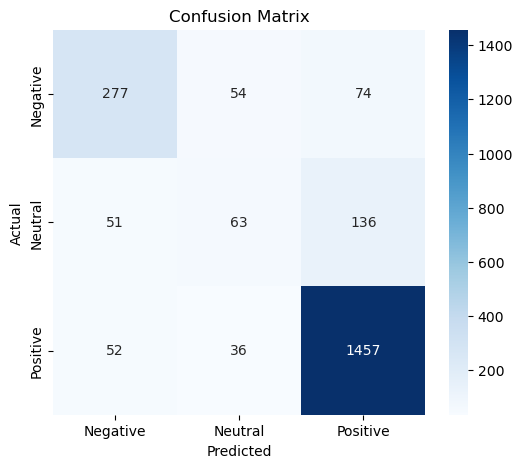

In [31]:

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


AUC: 0.8648169589256791


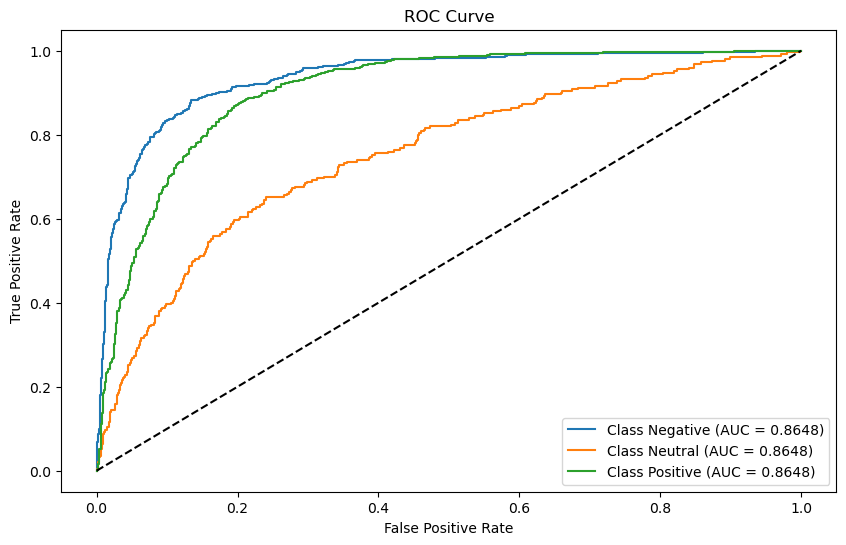

In [32]:
# Calculate AUC using the One-vs-Rest (OvR) approach
auc = roc_auc_score(pd.get_dummies(y_test).values, svm_probs, multi_class='ovr')
print("AUC:", auc)

# Initialize dictionaries for False Positive Rate, True Positive Rate, and thresholds
fpr = {}
tpr = {}
thresh = {}
classes = best_model.classes_

# Plot the ROC Curve for each class
plt.figure(figsize=(10, 6))
for i, class_label in enumerate(classes):
    fpr[class_label], tpr[class_label], thresh[class_label] = roc_curve(
        (y_test == class_label).astype(int), svm_probs[:, i]
    )
    plt.plot(fpr[class_label], tpr[class_label], label=f"Class {class_label} (AUC = {auc:.4f})")

# Plot the diagonal reference line
plt.plot([0, 1], [0, 1], 'k--')

# Add labels, title, and legend to the plot
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

In [33]:
# Cross-validation for robustness
cross_val_scores = cross_val_score(best_model, df["text"], df["label"], cv=3, scoring="accuracy")
print("Cross-Validation Accuracy Scores:", cross_val_scores)
print("Mean Cross-Validation Accuracy:", np.mean(cross_val_scores))

Cross-Validation Accuracy Scores: [0.80692664 0.80774475 0.80360065]
Mean Cross-Validation Accuracy: 0.8060906827247217
